In [4]:
import pandas as pd

df = pd.read_csv("../data/processed/cota_2024_features.csv")

In [6]:
from sklearn.linear_model import LinearRegression
import numpy as np

fuel_model = LinearRegression()

X_fuel = df[["FuelLoadProxy"]]
y_fuel = df["LapTimeSec"]

fuel_model.fit(X_fuel, y_fuel)

fuel_slope = fuel_model.coef_[0]

print("Estimated fuel effect per lap:", fuel_slope)

Estimated fuel effect per lap: 0.06044840993002947


In [8]:
df["FuelCorrectedLap"] = df["LapTimeSec"] - fuel_slope * df["FuelLoadProxy"]

In [12]:
driver_avg = df.groupby("Driver")["FuelCorrectedLap"].mean()

baseline = driver_avg.mean()

driver_delta = driver_avg - baseline

df["DriverPaceDelta"] = df["Driver"].map(driver_delta)

In [14]:
df["FullyCorrectedLap"] = (
    df["LapTimeSec"]
    - fuel_slope * df["FuelLoadProxy"]
    - df["DriverPaceDelta"]
)

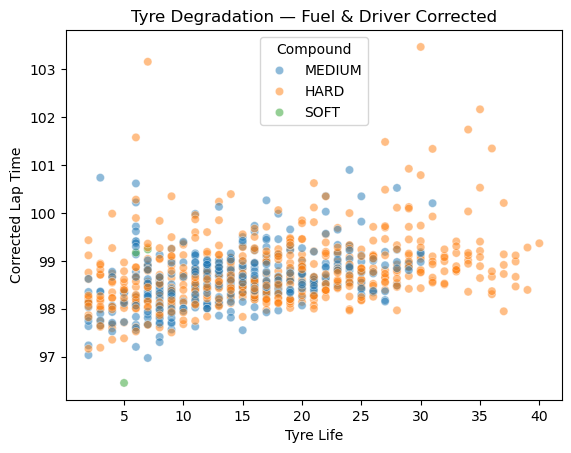

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.scatterplot(
    data=df,
    x="TyreLife",
    y="FullyCorrectedLap",
    hue="Compound",
    alpha=0.5
)

plt.title("Tyre Degradation — Fuel & Driver Corrected")
plt.xlabel("Tyre Life")
plt.ylabel("Corrected Lap Time")

plt.show()

In [32]:
deg_slopes = {}

df_filtered = df[df["TyreLife"] > 2]
df_filtered = df_filtered[
    (df_filtered["FullyCorrectedLap"] < df_filtered["FullyCorrectedLap"].quantile(0.98)) &
    (df_filtered["FullyCorrectedLap"] > df_filtered["FullyCorrectedLap"].quantile(0.02))
]

for compound in df_filtered["Compound"].unique():
    
    subset = df_filtered[df_filtered["Compound"] == compound]
    
    X = subset[["TyreLife"]]
    y = subset["FullyCorrectedLap"]
    
    model = LinearRegression()
    model.fit(X, y)
    
    deg_slopes[compound] = model.coef_[0]

print(deg_slopes)

{'MEDIUM': 0.029092765454778596, 'HARD': 0.01656262707199119, 'SOFT': 0.0664484099300324}


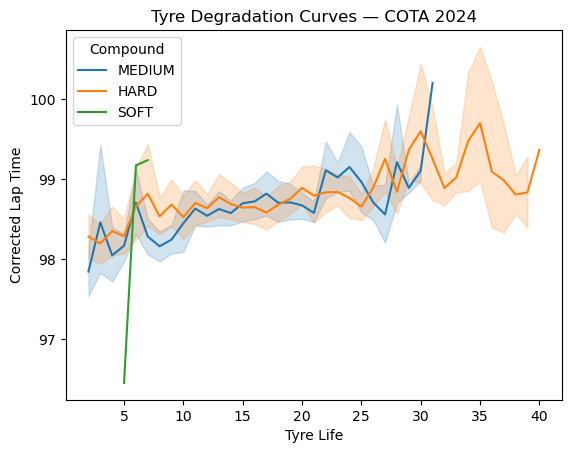

In [34]:
sns.lineplot(
    data=df,
    x="TyreLife",
    y="FullyCorrectedLap",
    hue="Compound",
    estimator="mean"
)

plt.title("Tyre Degradation Curves — COTA 2024")
plt.xlabel("Tyre Life")
plt.ylabel("Corrected Lap Time")

plt.show()

In [28]:
df[df["Compound"] == "SOFT"].shape

(3, 13)

In [30]:
df[df["Compound"] == "SOFT"]["TyreLife"].describe()

count    3.0
mean     6.0
std      1.0
min      5.0
25%      5.5
50%      6.0
75%      6.5
max      7.0
Name: TyreLife, dtype: float64

| Factor     | Estimated Effect |
| ---------- | ---------------- |
| Fuel Burn  | 0.060 sec/lap    |
| Soft Deg   | 0.066 sec/lap    |
| Medium Deg | 0.029 sec/lap    |
| Hard Deg   | 0.016 sec/lap    |
